In [21]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [48]:
df = pd.read_json('datos/2017.json')
df['fecha'] = pd.to_datetime(df[['impacto_presupuestario_anio', 'impacto_presupuestario_mes']].assign(day=1).rename(columns={
    'impacto_presupuestario_anio': 'year',
    'impacto_presupuestario_mes': 'month'
}))
df.drop(['impacto_presupuestario_anio'], axis=1, inplace=True)
df.drop(['impacto_presupuestario_mes'], axis=1, inplace=True)
df.columns

Index(['ejercicio_presupuestario', 'sector_id', 'sector_desc', 'subsector_id',
       'subsector_desc', 'caracter_id', 'caracter_desc', 'jurisdiccion_id',
       'jurisdiccion_desc', 'subjurisdiccion_id', 'subjurisdiccion_desc',
       'entidad_id', 'entidad_desc', 'servicio_id', 'servicio_desc',
       'programa_id', 'programa_desc', 'subprograma_id', 'subprograma_desc',
       'proyecto_id', 'proyecto_desc', 'actividad_id', 'actividad_desc',
       'obra_id', 'obra_desc', 'finalidad_id', 'finalidad_desc', 'funcion_id',
       'funcion_desc', 'inciso_id', 'inciso_desc', 'principal_id',
       'principal_desc', 'parcial_id', 'parcial_desc', 'subparcial_id',
       'subparcial_desc', 'clasificador_economico_8_digitos_id',
       'clasificador_economico_8_digitos_desc', 'fuente_financiamiento_id',
       'fuente_financiamiento_desc', 'ubicacion_geografica_id',
       'ubicacion_geografica_desc', 'unidad_ejecutora_id',
       'unidad_ejecutora_desc', 'prestamo_externo_id', 'prestamo_exter

In [49]:
df.nunique()[df.nunique()>1]

actividad_id                                8
actividad_desc                              8
funcion_id                                  3
funcion_desc                                3
inciso_id                                   5
inciso_desc                                 5
principal_id                                9
principal_desc                             23
parcial_id                                 10
parcial_desc                               57
subparcial_id                              70
subparcial_desc                           122
clasificador_economico_8_digitos_id        13
clasificador_economico_8_digitos_desc      11
fuente_financiamiento_id                    2
fuente_financiamiento_desc                  2
ubicacion_geografica_id                    25
ubicacion_geografica_desc                  25
credito_presupuestado                     256
credito_vigente                           465
credito_comprometido                     3006
credito_devengado                 

In [50]:
df['inciso_desc'].unique()

array(['Gastos en personal', 'Bienes de consumo',
       'Servicios no personales', 'Bienes de uso', 'Transferencias'],
      dtype=object)

In [62]:
df_salarios = df[(df['inciso_desc'] == 'Gastos en personal') & (df['clasificador_economico_8_digitos_desc'] == 'Sueldos y salarios')].copy()
df_salarios.nunique()[df_salarios.nunique()>1]

principal_id              3
principal_desc            3
parcial_id                5
parcial_desc              7
subparcial_desc           7
credito_presupuestado    10
credito_vigente          12
credito_comprometido     86
credito_devengado        84
credito_pagado           88
fecha                    12
dtype: int64

In [66]:
df_salarios['parcial_desc'].unique()

array(['Retribución del cargo', 'Retribuciones que no hacen al cargo',
       'Sueldo anual complementario', 'Retribuciones extraordinarias',
       'Retribuciones por contratos', 'Adicionales al contrato',
       'Contratos especiales'], dtype=object)

<Axes: xlabel='fecha'>

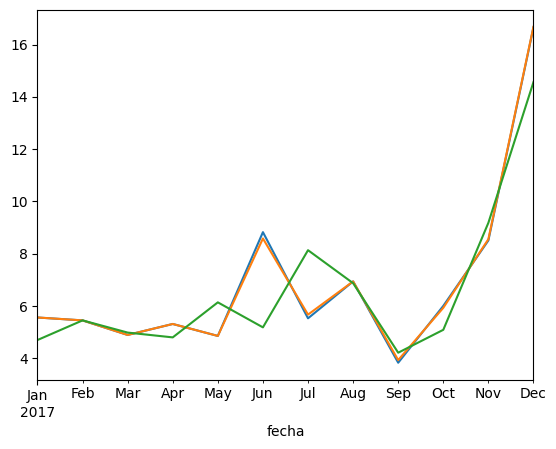

In [ ]:
# df_salarios.groupby('fecha')['credito_presupuestado'].sum().plot()
# df_salarios.groupby('fecha')['credito_vigente'].sum().plot()
df_salarios.groupby('fecha')['credito_comprometido'].sum().plot()
df_salarios.groupby('fecha')['credito_devengado'].sum().plot()
df_salarios.groupby('fecha')['credito_pagado'].sum().plot()

In [76]:
df_salarios_mensual = df_salarios.groupby('fecha')['credito_pagado'].sum()
df_salarios_mensual

fecha
2017-01-01     4.700579
2017-02-01     5.451461
2017-03-01     4.985429
2017-04-01     4.801691
2017-05-01     6.141304
2017-06-01     5.185053
2017-07-01     8.135596
2017-08-01     6.874390
2017-09-01     4.215813
2017-10-01     5.091146
2017-11-01     9.183274
2017-12-01    14.564672
Name: credito_pagado, dtype: float64

In [100]:
df_salarios_mensual = []
for anio in range(2017, 2027):
    df = pd.read_json(f'datos/{anio}.json')
    df['fecha'] = pd.to_datetime(df[['impacto_presupuestario_anio', 'impacto_presupuestario_mes']].assign(day=1).rename(columns={
        'impacto_presupuestario_anio': 'year',
        'impacto_presupuestario_mes': 'month'
    }))
    df.drop(['impacto_presupuestario_anio'], axis=1, inplace=True)
    df.drop(['impacto_presupuestario_mes'], axis=1, inplace=True)
    df_salarios = df[(df['inciso_desc'] == 'Gastos en personal') & (df['clasificador_economico_8_digitos_desc'] == 'Sueldos y salarios')].copy()
    df_salarios_mensual.append(df_salarios.groupby('fecha')['credito_devengado'].sum())
df_salarios_mensual = pd.concat(df_salarios_mensual).to_frame().reset_index()
df_salarios_mensual.rename(columns={'credito_devengado': 'salarios'}, inplace=True)
df_salarios_mensual['salarios_prop']=df_salarios_mensual['salarios'] / df_salarios_mensual['salarios'].iloc[0]
df_salarios_mensual

,fecha,salarios,salarios_prop
0,2017-01-01,5.562325,1.000000
1,2017-02-01,5.451461,0.980069
2,2017-03-01,4.895005,0.880029
3,2017-04-01,5.314525,0.955450
4,2017-05-01,4.857149,0.873223
...,...,...,...
107,2025-12-01,314.945304,56.621160
108,2026-01-01,228.060928,41.001006
109,2026-02-01,272.680872,49.022821
110,2026-03-01,292.407962,52.569376


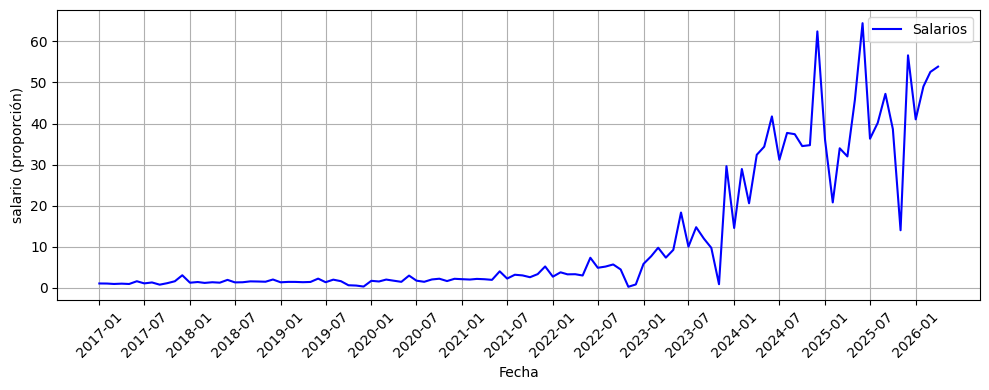

In [101]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_salarios_mensual['fecha'], df_salarios_mensual['salarios_prop'], label='Salarios', color='blue')

ax.set_xlabel('Fecha')
ax.set_xticks(df_salarios_mensual['fecha'][::6])
ax.set_xticklabels(df_salarios_mensual['fecha'][::6].dt.strftime('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel('salario (proporción)')
#ax.set_yscale('log')

ax.legend()

ax.grid()
plt.tight_layout()
plt.show()

In [ ]:
# https://datos.gob.ar/el/dataset/sspm-ipc-nacional-tasas-variacion-mensual-por-categorias-base-dic-2016/archivo/sspm_173.1
ipc_df = pd.read_csv('datos/ipc-categorias-tasas-variacionmensual-basedic-2016.csv') 
ipc_df['indice_tiempo'] = pd.to_datetime(ipc_df['indice_tiempo'], format='%Y-%m-%d')
ipc_df = ipc_df.rename(columns={'indice_tiempo': 'fecha'})
ipc_df['ipc_nucleo_acumulada'] = (1 + ipc_df['ipc_nucleo']).cumprod()
ipc_df['ipc_regulados_acumulada'] = (1 + ipc_df['ipc_regulados']).cumprod()
ipc_df['estacionales_acumulada'] = (1 + ipc_df['estacionales']).cumprod()

ipc_df.head()

,fecha,estacionales,ipc_nucleo,ipc_regulados,ipc_nucleo_acumulada,ipc_regulados_acumulada,estacionales_acumulada
0,2016-12-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-01,0.016969,0.015039,0.018183,1.015039,1.018183,1.016969
2,2017-02-01,0.006270,0.016813,0.040398,1.032105,1.059316,1.023345
3,2017-03-01,0.023964,0.019331,0.038460,1.052057,1.100057,1.047868
4,2017-04-01,0.032446,0.021114,0.040536,1.074270,1.144649,1.081867


In [104]:
df_merged = df_salarios_mensual.merge(ipc_df, on='fecha', how='left')
df_merged['ipc_nucleo_acumulada'] = (1 + df_merged['ipc_nucleo']).cumprod()
df_merged['ipc_regulados_acumulada'] = (1 + df_merged['ipc_regulados']).cumprod()
df_merged['estacionales_acumulada'] = (1 + df_merged['estacionales']).cumprod()

df_merged.head()

,fecha,salarios,salarios_prop,estacionales,ipc_nucleo,ipc_regulados,ipc_nucleo_acumulada,ipc_regulados_acumulada,estacionales_acumulada
0,2017-01-01,5.562325,1.000000,0.016969,0.015039,0.018183,1.015039,1.018183,1.016969
1,2017-02-01,5.451461,0.980069,0.006270,0.016813,0.040398,1.032105,1.059316,1.023345
2,2017-03-01,4.895005,0.880029,0.023964,0.019331,0.038460,1.052057,1.100057,1.047868
3,2017-04-01,5.314525,0.955450,0.032446,0.021114,0.040536,1.074270,1.144649,1.081867
4,2017-05-01,4.857149,0.873223,0.008013,0.016568,0.010405,1.092069,1.156559,1.090536


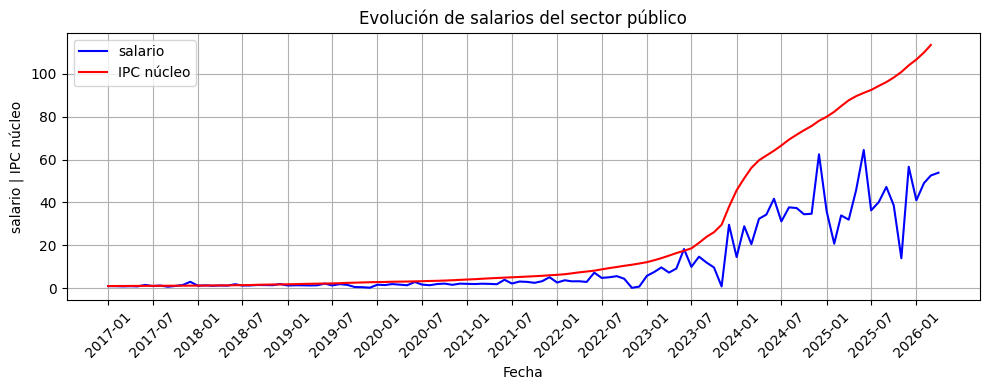

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_merged['fecha'], df_merged['salarios_prop'], label='salario', color='blue')
ax.plot(df_merged['fecha'], df_merged['ipc_nucleo_acumulada'], label='IPC núcleo', color='red')

ax.set_xlabel('Fecha')
ax.set_title('Evolución de salarios del sector público')
ax.set_xticks(df_merged['fecha'][::12])
ax.set_xticklabels(df_merged['fecha'][::12].dt.strftime('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel('salario | IPC núcleo')
#ax.set_yscale('log')

ax.legend()

ax.grid()
plt.tight_layout()
plt.show()

In [114]:
df_merged['salarios_prop_real'] = 100*df_merged['salarios_prop'] / df_merged['ipc_nucleo_acumulada'] 

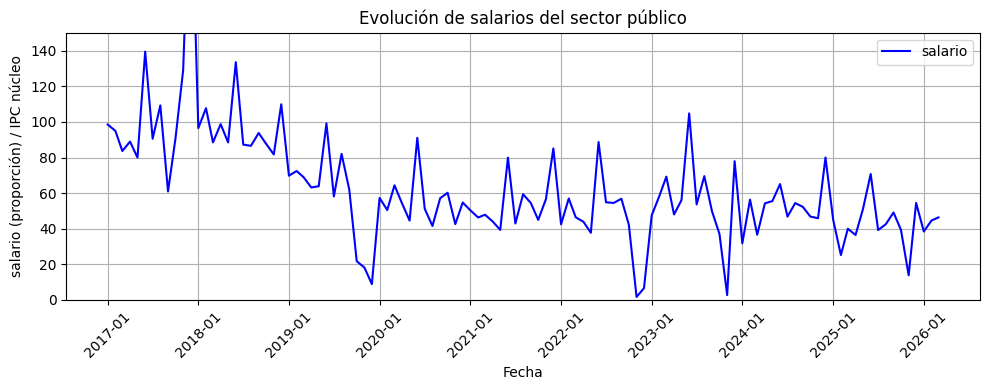

In [117]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_merged['fecha'], df_merged['salarios_prop_real'], label='salario', color='blue')

ax.set_xlabel('Fecha')
ax.set_title('Evolución de salarios del sector público')
ax.set_xticks(df_merged['fecha'][::12])
ax.set_xticklabels(df_merged['fecha'][::12].dt.strftime('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel('salario (proporción) / IPC núcleo')
ax.set_ylim(0.0, 150)
#ax.set_yscale('log')

ax.legend()

ax.grid()
plt.tight_layout()
plt.show()